In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# Display plots nicely
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


# Mutual Fund Analysis - Exploratory Data Analysis (EDA)

**Author:** Harsha

**Project:** Bluestock Mutual Fund Analysis

## Objective
Perform exploratory data analysis on mutual fund datasets to identify trends, investor behavior, fund performance, and market insights using Python visualizations.

In [37]:
# Load cleaned datasets

nav = pd.read_csv("data/processed/02_nav_history.csv")

transactions = pd.read_csv(
    "data/processed/08_investor_transactions.csv"
)

performance = pd.read_csv(
    "data/processed/07_scheme_performance.csv"
)

fund = pd.read_csv(
    "data/raw/01_fund_master.csv"
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [38]:
print("NAV Shape:", nav.shape)

print("Transactions Shape:", transactions.shape)

print("Performance Shape:", performance.shape)

print("Fund Shape:", fund.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)
Fund Shape: (40, 15)


In [39]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
transactions.head()

In [ ]:
performance.head()

In [ ]:
fund.head()

In [40]:
# Convert date column to datetime

nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [41]:
nav_merged = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [43]:
fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)
fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr"
)
fig.show()

In [44]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

In [45]:
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    line_width=0
)

## Insight 1

- Daily NAV values show the overall performance trend of all 40 mutual fund schemes.
- The highlighted green region represents the 2023 bull market, while the red region represents the 2024 market correction.
- Most equity-oriented schemes experienced steady NAV growth over the analysis period.

In [46]:
print(performance.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

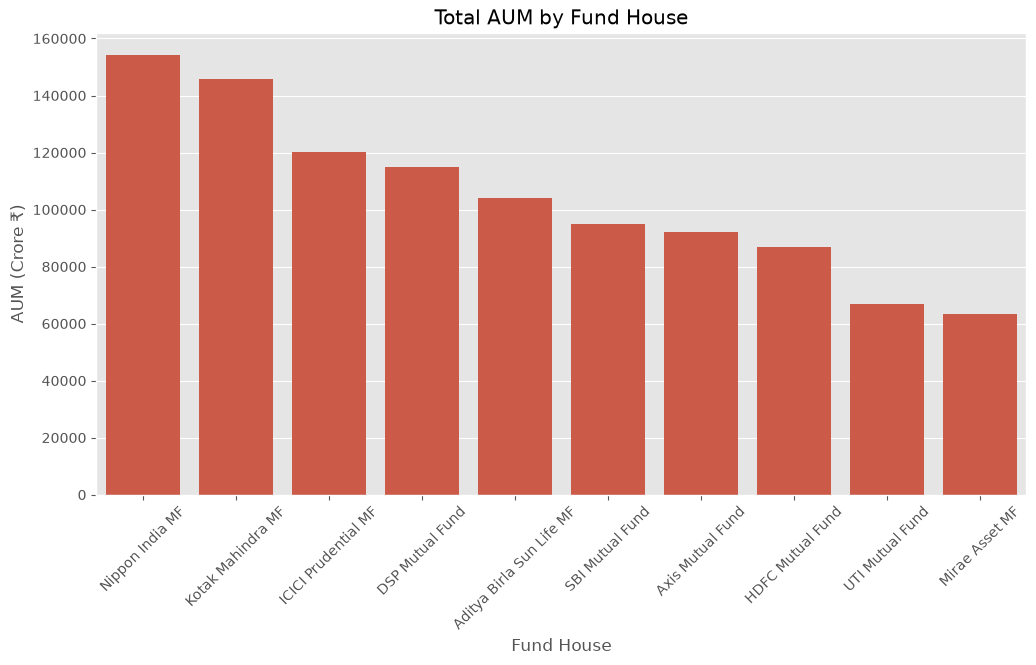

In [47]:
aum_by_house = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .reset_index()
)
aum_by_house = aum_by_house.sort_values(
    by="aum_crore",
    ascending=False
)
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_by_house,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)

plt.title("Total AUM by Fund House")

plt.xlabel("Fund House")

plt.ylabel("AUM (Crore ₹)")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 2

- SBI Mutual Fund has one of the highest Assets Under Management (AUM).
- Larger fund houses dominate the mutual fund industry in terms of total assets.
- AUM varies significantly across fund houses.

In [48]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
sip = transactions[
    transactions["transaction_type"] == "SIP"
]
sip["month"] = sip["transaction_date"].dt.to_period("M").astype(str)
monthly_sip = (
    sip.groupby("month")["amount_inr"]
    .sum()
    .reset_index()
)

import plotly.express as px

fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total SIP Amount (₹)"
)
fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr"
)
fig.show()

In [49]:
max_row = monthly_sip.loc[
    monthly_sip["amount_inr"].idxmax()
]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["amount_inr"],
    text="Highest SIP Inflow",
    showarrow=True,
    arrowhead=2
)
fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr"
)

fig.show()

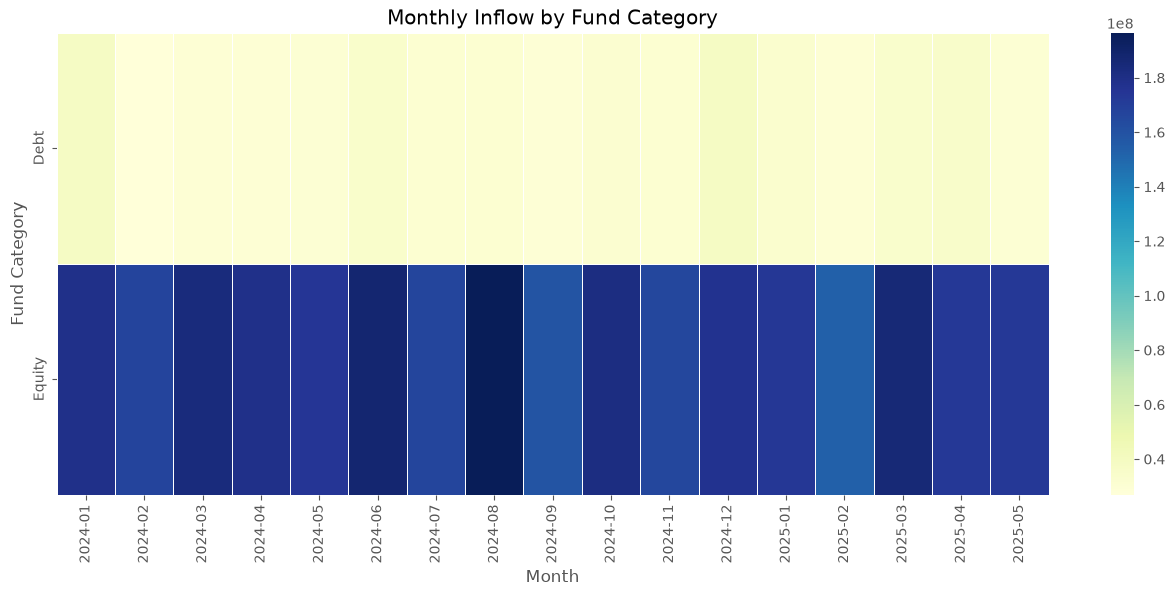

In [50]:
transactions_category = transactions.merge(
    fund[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

transactions_category["month"] = (
    pd.to_datetime(transactions_category["transaction_date"])
    .dt.to_period("M")
    .astype(str)
)

heatmap_data = (
    transactions_category
    .groupby(["category", "month"])["amount_inr"]
    .sum()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(
    index="category",
    columns="month",
    values="amount_inr"
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_pivot,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Inflow by Fund Category")

plt.xlabel("Month")

plt.ylabel("Fund Category")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

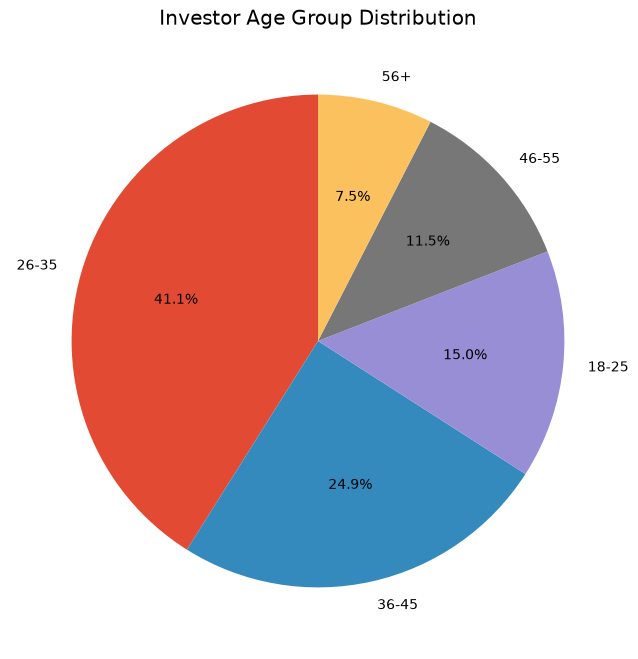

In [51]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")

plt.show()

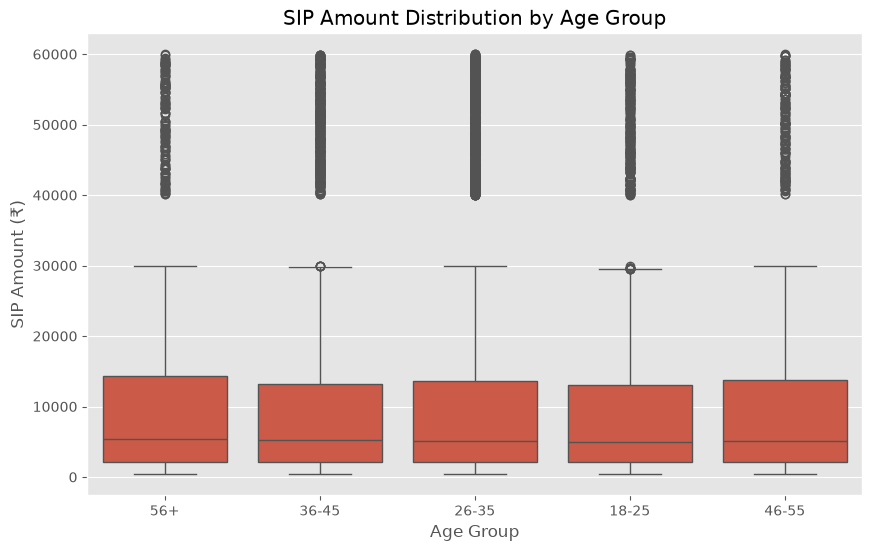

In [52]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("SIP Amount (₹)")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 6

- The box plot compares SIP investment amounts across different age groups.
- Wider boxes and longer whiskers indicate greater variation in investment amounts.
- Outliers represent unusually high SIP investments.

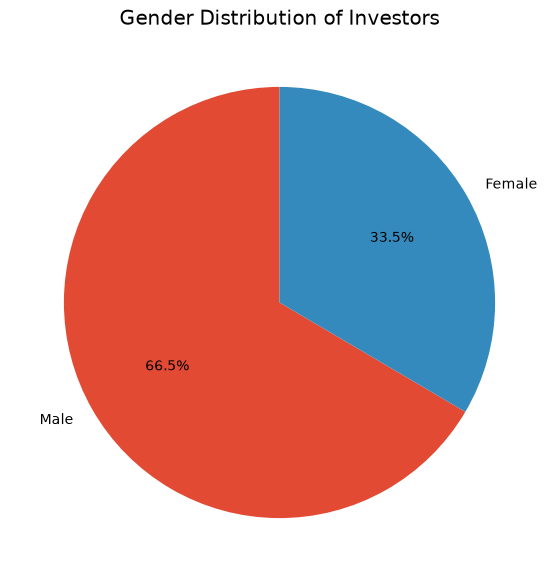

In [53]:
plt.figure(figsize=(7,7))

gender_counts = transactions["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 7

- The chart shows the proportion of male and female investors.
- It provides an overview of gender participation in mutual fund investments.

In [54]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

In [55]:
state_sip = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_sip.head()

,state,amount_inr
0,Madhya Pradesh,20682243
1,Punjab,20140064
2,Telangana,18620216
3,Tamil Nadu,18404368
4,Gujarat,18378904


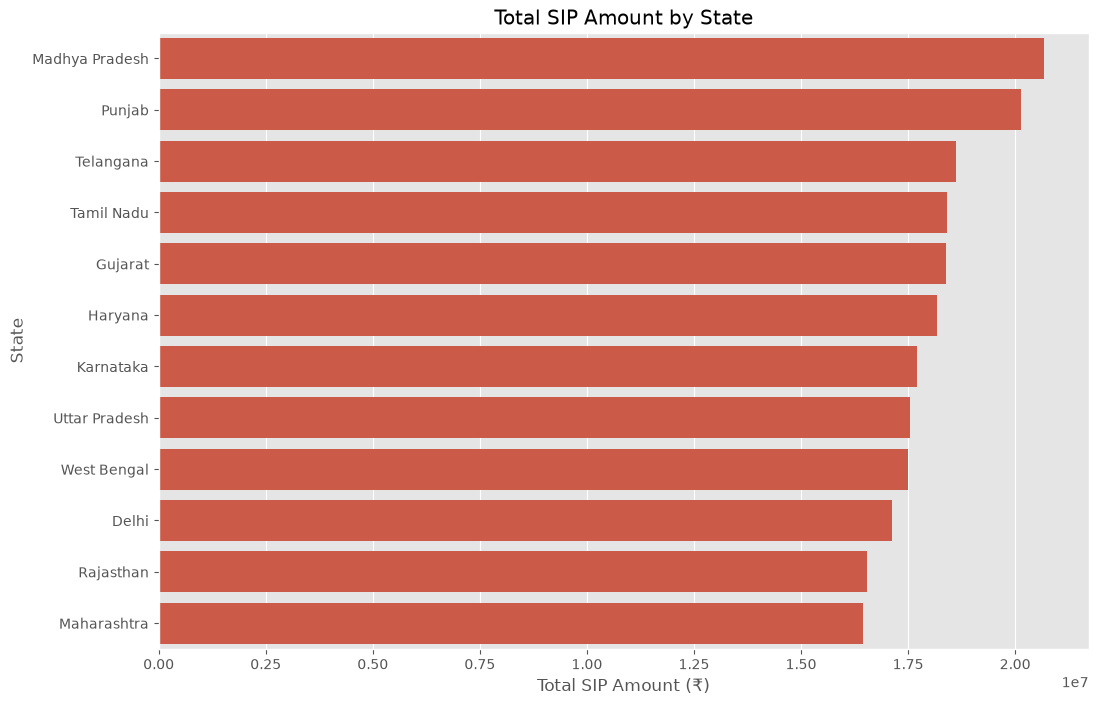

In [56]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total SIP Amount by State")

plt.xlabel("Total SIP Amount (₹)")

plt.ylabel("State")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 8

- The horizontal bar chart compares total SIP investments across different states.
- States with longer bars have attracted larger SIP investments.
- Geographic analysis helps identify regions with stronger mutual fund participation.

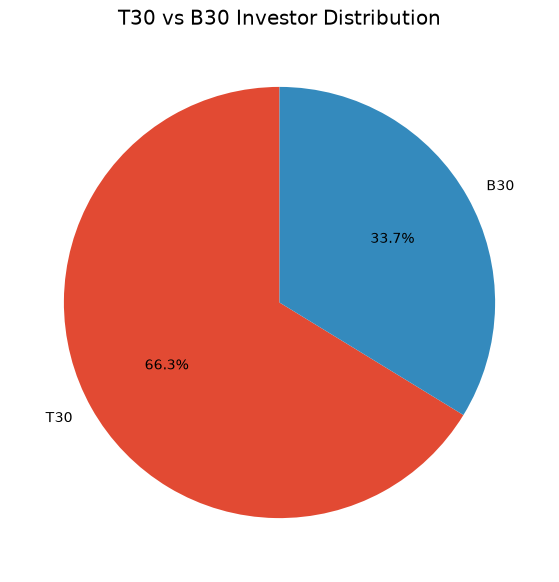

In [57]:
city_tier = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Insight 9

- The pie chart compares investor participation between T30 and B30 cities.
- A higher B30 share indicates increasing mutual fund adoption in smaller cities.
- The distribution highlights the geographical reach of mutual fund investments.

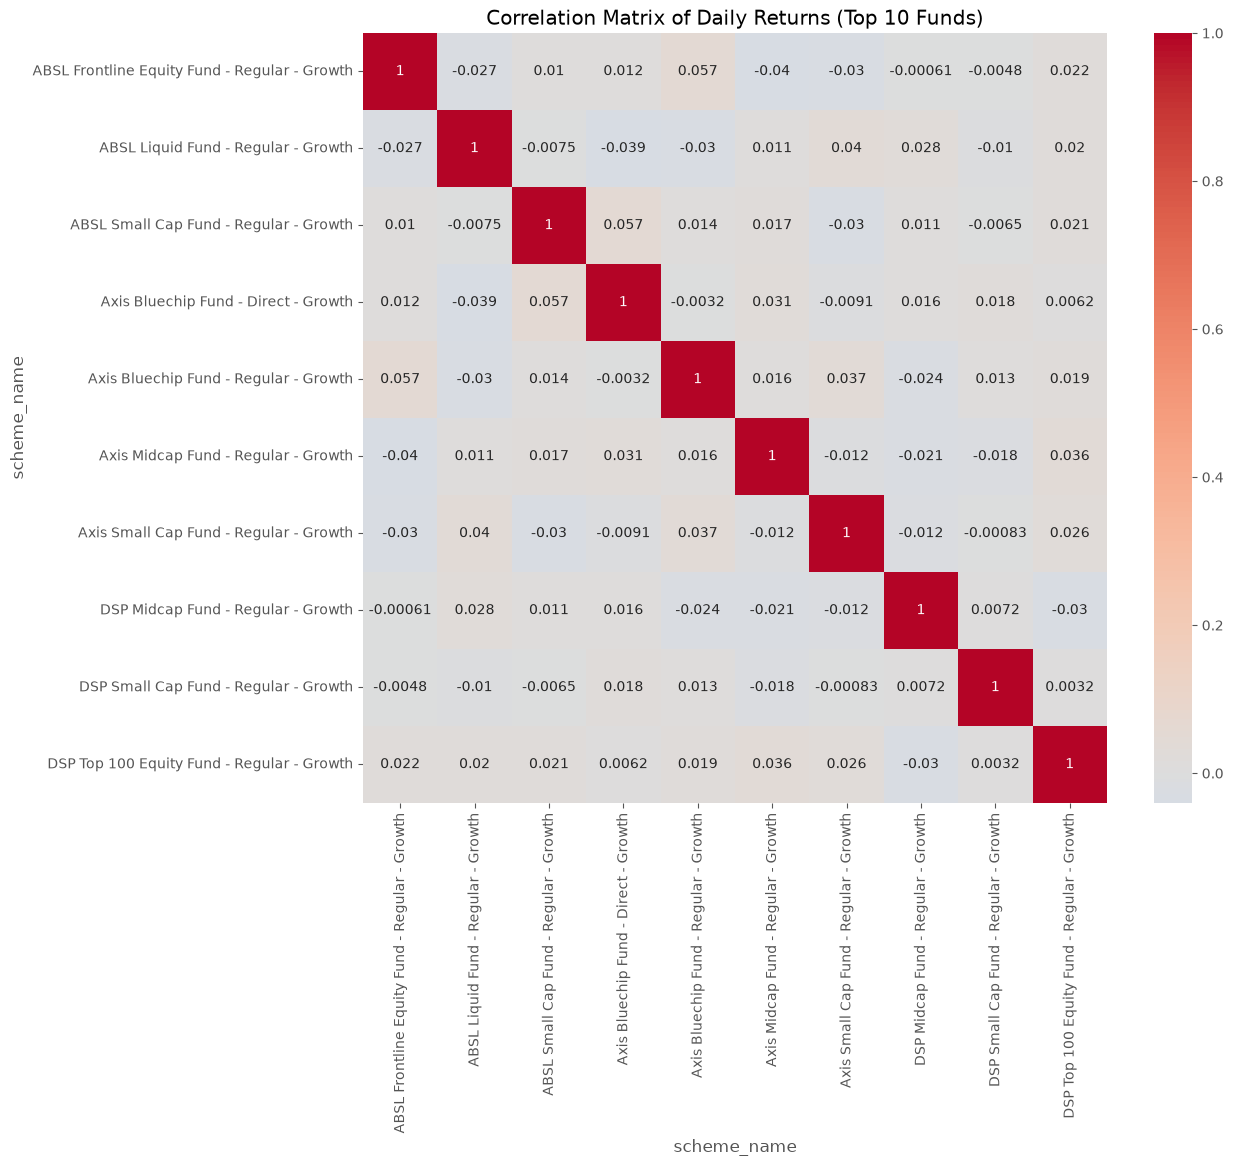

In [58]:
nav_pivot = nav_merged.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

nav_pivot.head()
selected_funds = nav_pivot.iloc[:, :10]
daily_returns = selected_funds.pct_change()
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Daily Returns (Top 10 Funds)")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Insight 10

- Funds with correlation values close to **1** tend to move together.
- Lower correlations indicate diversification opportunities.
- Correlation analysis helps investors build balanced portfolios.

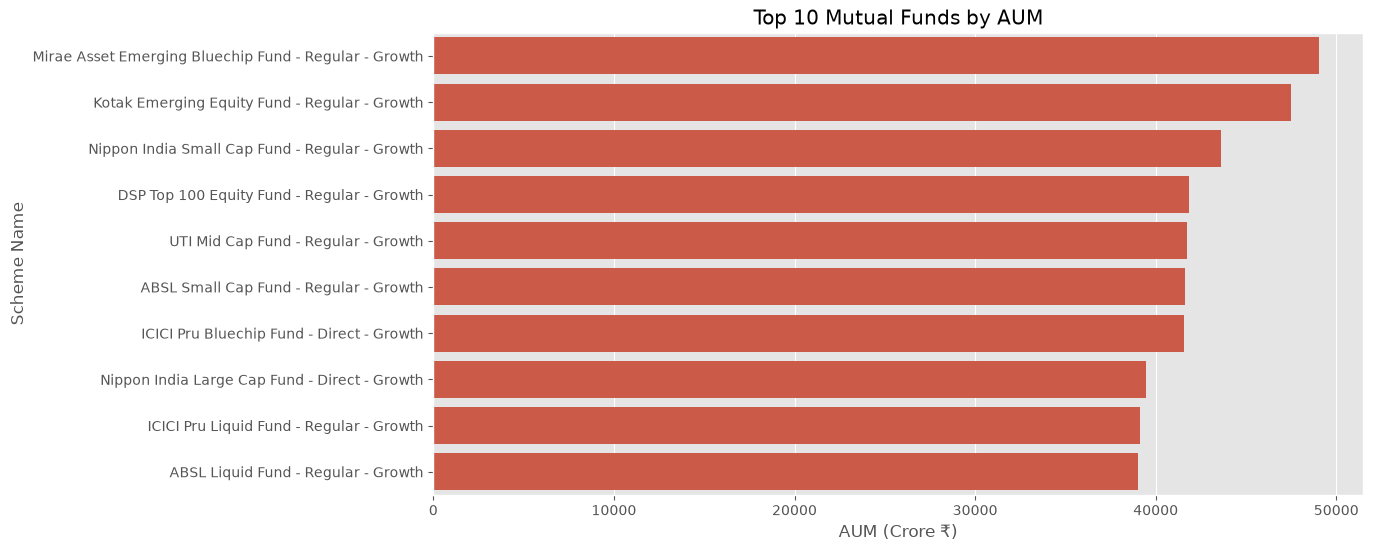

In [59]:
top_aum = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("AUM (Crore ₹)")
plt.ylabel("Scheme Name")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 11

The top 10 mutual funds account for a significant share of total Assets Under Management, indicating strong investor preference for established schemes.

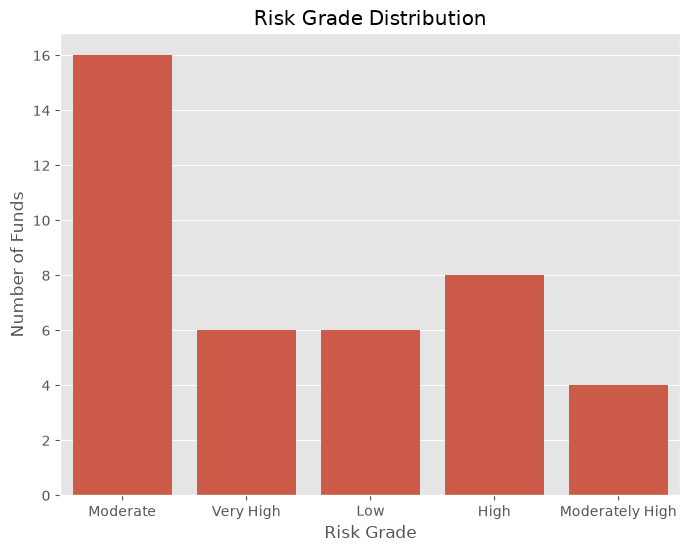

In [60]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 12

Most mutual funds fall under Moderate to Very High risk categories, reflecting the dominance of equity-oriented schemes.

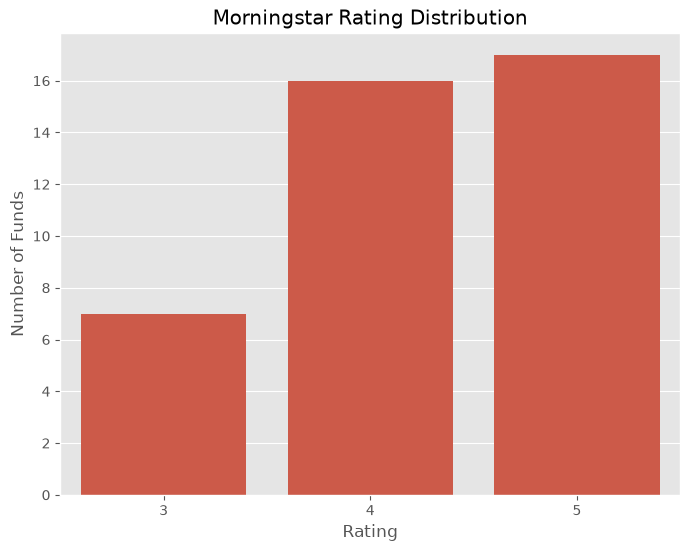

In [61]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 13

The majority of schemes have ratings between 3 and 5, indicating generally good historical performance.

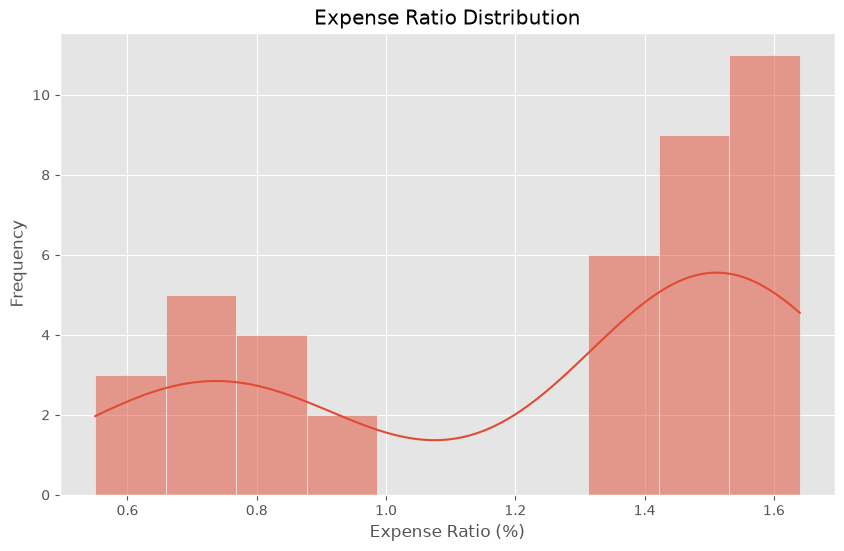

In [62]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight 14

Most mutual funds maintain expense ratios below 2%, making them cost-effective investment options.

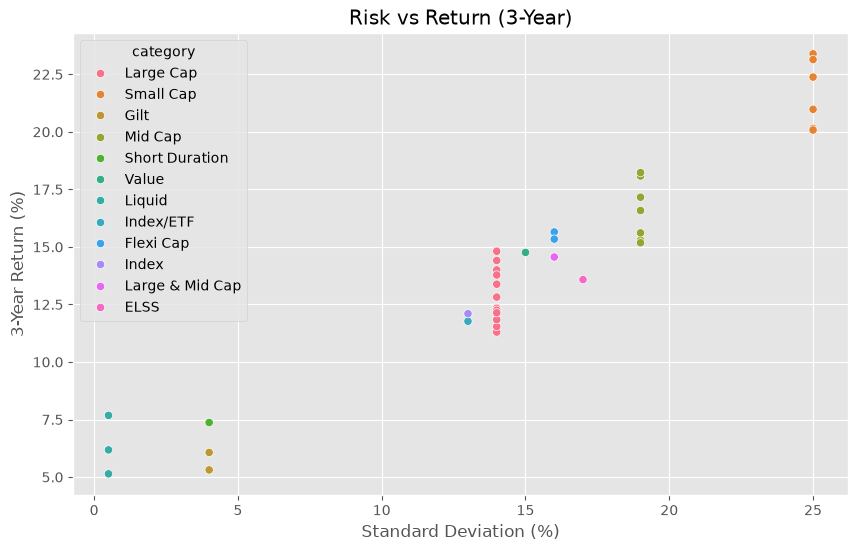

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="category"
)

plt.title("Risk vs Return (3-Year)")
plt.xlabel("Standard Deviation (%)")
plt.ylabel("3-Year Return (%)")
plt.savefig("charts/chart_name.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 15

Higher-risk funds generally deliver higher long-term returns, though some categories achieve competitive returns with comparatively lower volatility.

# Final Conclusion

The exploratory data analysis identified trends in NAV movement, investor demographics, transaction behavior, fund performance, risk, and assets under management.

Key observations include:

- Strong variation in AUM across fund houses.
- Consistent SIP activity throughout the analysis period.
- Equity funds dominate investor preference.
- Moderate and high-risk funds form the majority of schemes.
- Expense ratios remain within a reasonable range for most funds.
- Correlation analysis highlights diversification opportunities across mutual funds.